## Módulo III: Preprocesamiento 

### Datos nulos  y su tratamiento I

#### Actividad I 
* Tome de inversiones en educación del estado de Jalisco.
* Hacer un análisis de nulos. 
    * Revise cantidad en cada variable. 
* Llenar con media/moda según corresponda a datos numéricos/categóricos.
    * Evaluar cambios en distribuciones. 
* Revise el comportamiento en un modelo de árboles. 

#### Actividad II

* Tome el set de evaluaciones de plantes educativos del estado de Jalisco.
* Tenga en cuenta que cada renglón representa un plantel educativo (una escuela). 
* Haga un análisis de nulos.
    * Tome un threshold mayor a 50% y diga cuáles variables superan este nivel de nulos. 
    * De las variables resultantes del punto anterior teorice: ¿Por qué podrían tener un nivel alto de nulos? 
* Tome las variables con un nivel menor a 50% de sus datos en nulos y rellene numéricos con media y categóricos con moda. Responda: 
    * ¿Cuáles variables pueden ser llenadas de manera segura? ¿Por qué? 



In [15]:
import pandas as pd 
import os 
from matplotlib import pyplot as plt 


plt.style.use('ggplot')

#### Datos nulos
En la práctica puede faltar un dato por múltiples razones:

* Errores en la captura.
    * Typos, fallas de los capturistas, errores en la entrevista.
* No existe el dato.
    * Veces que se ha quedado sin gasolina a una bici.
* No es válido el dato para la población.
    * Veces que has cambiado el INE a población menores de 18 años.
    
Es importante entender el origen de un dato nulo para saber cómo y si lo podemos reemplazar o no, no querríamos remplazar un dato que no tenga sentido como los ejemplos anteriores.


In [16]:
df = pd.read_csv('inversiones_with_regex.csv')

In [17]:
df.head()

,Unnamed: 0.1,Unnamed: 0,MUNICIPIO,CLAVE_CT,RESPONSABLE,TURNO,NOMBRE_CT,DIRECTOR,NIVEL,MATRICULA,...,AULAS_PROVISIONALES_OBSERVACION_otro_uso,AULAS_PROVISIONALES_OBSERVACION_sust_2013,AULAS_PROVISIONALES_OBSERVACION_sust_2014,AULAS_PROVISIONALES_OBSERVACION_sust_2015,CONECTIVIDAD_mbs,OBSERVACION_PEC2013_processed,OBSERVACION_PEC2014_processed,OBSERVACION_MOBILIARIO_PIEZAS_processed,OBSERVACION_MOBILIARIO_ALUMNOS_processed,OBSERVACION_MOBILIARIO_MATRICULA_processed
0,0,0,AHUALULCO DE MERCADO,14DPR0273Q,R,MATUTINO,5_DE_MAYO,ANGELICA_IVETT_FLORES_CARDENAS,PRIMARIA,329,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,0.0,0.0,0.0
1,1,1,AHUALULCO DE MERCADO,14EPR0482V,R,MATUTINO,VALENTIN_GOMEZ_FARIAS,MARIA_EDITH_CRUZ_CASTAAAEDA,PRIMARIA,94,...,NaN,NaN,NaN,NaN,2.0,0.0,NaN,0.0,0.0,0.0
2,2,2,AHUALULCO DE MERCADO,14EJN0200G,R,MATUTINO,EMILIANO_ZAPATA,HILDA_GARCIA_VEGA,PREESCOLAR,144,...,NaN,NaN,NaN,NaN,2.0,0.0,NaN,0.0,0.0,0.0
3,3,3,AHUALULCO DE MERCADO,14DJN0155L,R,MATUTINO,JAVIER_URIBE,MARIA_ELENA_ARELLANO_NUAAEZ,PREESCOLAR,111,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,0.0,0.0,0.0
4,4,4,AHUALULCO DE MERCADO,14EPR0014B,R,MATUTINO,JOSE_MA_MERCADO,MARIA_CONSEPCION_PINZON_RODRIGUEZ,PRIMARIA,289,...,NaN,NaN,NaN,NaN,2.0,NaN,0.0,0.0,0.0,0.0


Primero eliminemos los "Unnamed" y después contabilicemos el nivel de datos nulos.

In [18]:
df.drop([c for c in df if 'Unnamed' in c], axis=1, inplace=True)

In [19]:
df.isnull().sum()

MUNICIPIO                                        0
CLAVE_CT                                         0
RESPONSABLE                                      0
TURNO                                            0
NOMBRE_CT                                        0
                                              ... 
OBSERVACION_PEC2013_processed                 7503
OBSERVACION_PEC2014_processed                 7139
OBSERVACION_MOBILIARIO_PIEZAS_processed       6687
OBSERVACION_MOBILIARIO_ALUMNOS_processed      6687
OBSERVACION_MOBILIARIO_MATRICULA_processed    6687
Length: 63, dtype: int64

In [20]:
nulos_relativos = df.isnull().mean()

<Axes: >

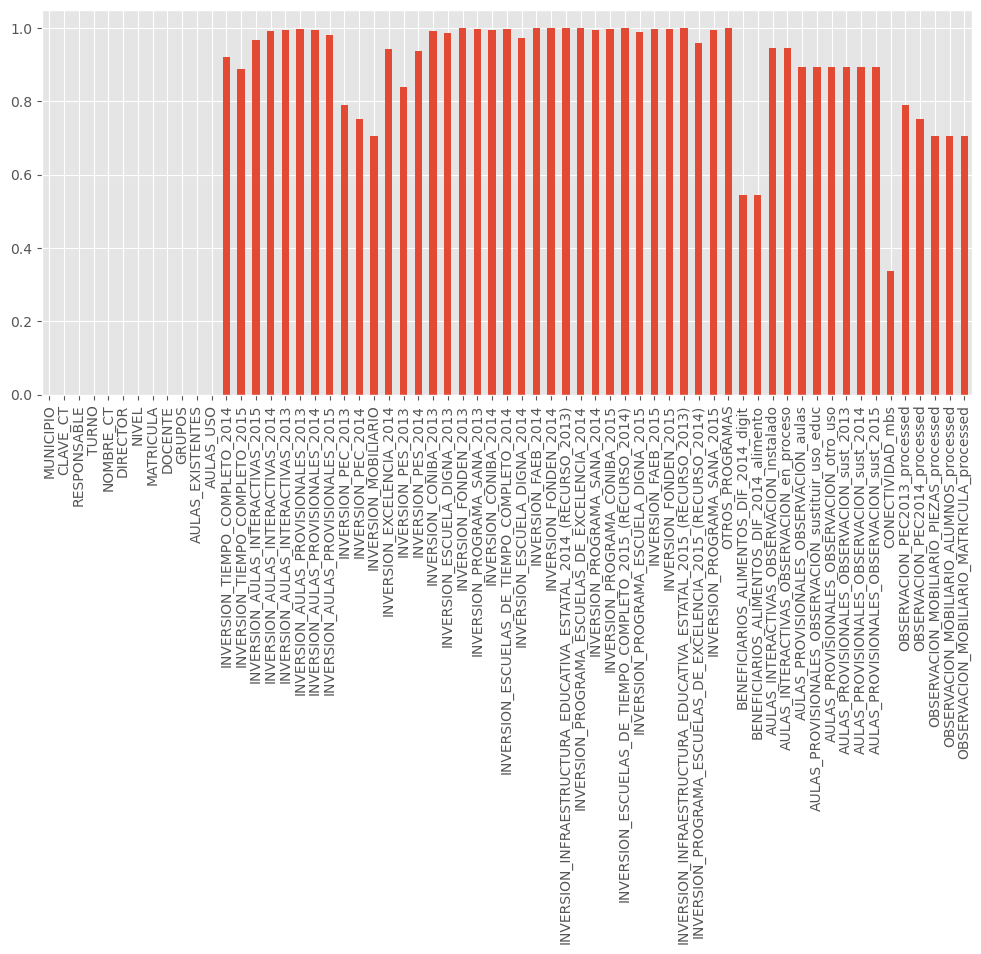

In [21]:
nulos_relativos.plot(kind='bar', figsize=(12,5))

Hay muchas variables con una altísima cantidad de nulos. 

Si bien no hay una regla para eliminar nulos, sí podemos hacer un análisis de valor para evaluar la viabilidad de la variable. 

Podemos sustituir nulos con: 

* Media/mediana.
* Moda. 
* Valores atípicos. 


La última estrategia es recomendada si se usarán modelos de árboles. 

#### Análisis de valor de los nulos 

Este análisis se propone cuando existe una variable de respuesta contra la cual comparar nuestros elementos. 

Este análisis consiste en hacer una agrupación por cuantiles y/o categorías de la variable predictora y calcular el promedio de la variable de respuesta en cada uno de los elementos ya mencionados. 

Si la variable **sin alterar nulos** no muestra relación con el análisis anterior con la target ni una correlación significativa (~>0.65) se recomienda eliminar. 


A continuación un ejemplo de cómo se realizaría el análisis _si la variable objetivo fuera `docentes`_. 

In [22]:
variable = 'INVERSION_MOBILIARIO'
target = 'DOCENTE'

In [23]:
quintiles = pd.qcut(df[variable], q=5)
quintiles

0       (212739.14, 1105266.48]
1        (83466.624, 212739.14]
2        (83466.624, 212739.14]
3         (41475.72, 83466.624]
4       (212739.14, 1105266.48]
                 ...           
9484                        NaN
9485                        NaN
9486                        NaN
9487                        NaN
9488                        NaN
Name: INVERSION_MOBILIARIO, Length: 9489, dtype: category
Categories (5, interval[float64, right]): [(4218.239, 20233.088] < (20233.088, 41475.72] < (41475.72, 83466.624] < (83466.624, 212739.14] < (212739.14, 1105266.48]]

In [24]:
tmp = df[[variable, target]].copy()

C:\Users\hecto\AppData\Local\Temp\ipykernel_6304\881921258.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby('quintiles')[target].mean().plot(marker='o', rot=90)


<Axes: xlabel='quintiles'>

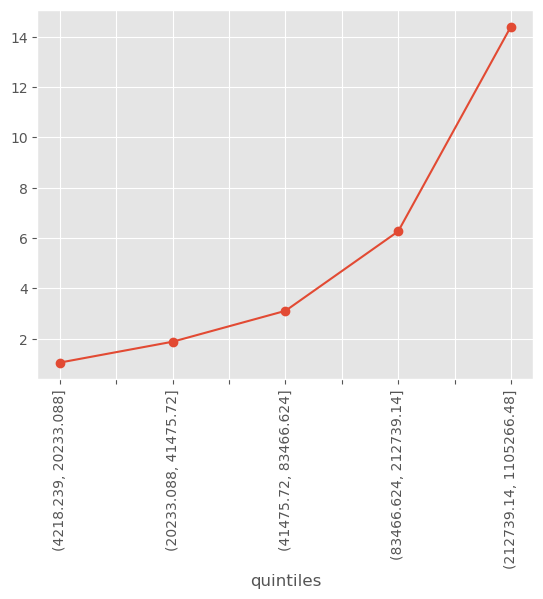

In [25]:
tmp['quintiles'] = quintiles.values
tmp.groupby('quintiles')[target].mean().plot(marker='o', rot=90)

En este caso parece existir una relación interesante por lo que valdría la pena mantener la variable. 

Esta variable tiene ~70% de datos nulos, se propondía realizar este ejercicio para las variables con alto contenido de datos nulos y determinar una de las siguientes dos opciones:

* Variables a eliminar independientemente de la cantidad de nulos. 
* Un porcentaje de nulos a mantener. 


En este caso no tenemos una variable de respuesta por lo que tomaremos otro _approach_ y eliminaremos nulos con base en un _threshold_.

#### Llenado con base en estadísticos en datos númericos

C:\Users\hecto\AppData\Local\Temp\ipykernel_6304\610835031.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  copy[variable].fillna(copy[variable].mean(), inplace=True)
C:\Users\hecto\AppData\Local\Temp\ipykernel_6304\610835031.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


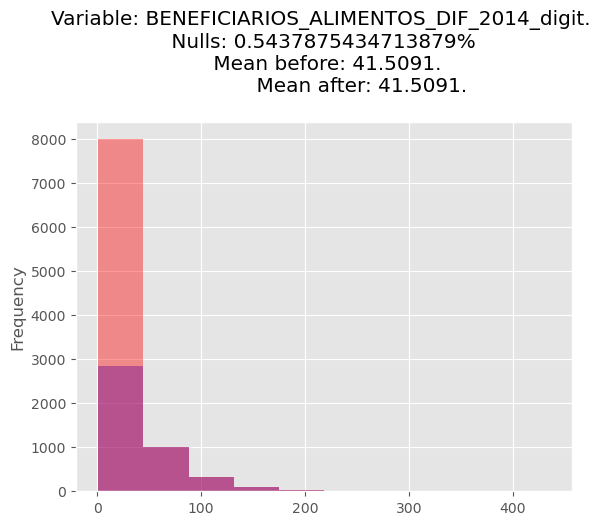

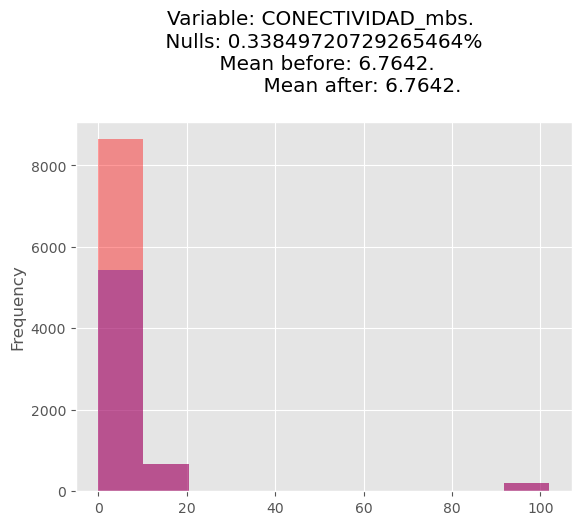

In [26]:
copy = df.copy()
numeric_cols = df.select_dtypes(include=['number']).columns

threshold = 0.7

for variable in numeric_cols:
    nulls = copy[variable].isnull().mean()

    if 0 < nulls <= threshold:
        copy[variable].fillna(copy[variable].mean(), inplace=True)

        fig, ax = plt.subplots()

        df[variable].plot(kind='hist', color='blue', ax=ax, alpha=0.4)

        mean_before = df[variable].mean().round(4)

        copy[variable].plot(kind='hist', color='red', ax=ax, alpha=0.4)

        mean_after = copy[variable].mean().round(4)

        ax.set_title(
            f"""Variable: {variable}. \n Nulls: {nulls}% \n Mean before: {mean_before}.
            Mean after: {mean_after}.
            """
        )

En este caso observamos que:
* La distribución tiene la misma forma. 
* Las medias no cambiaron antes ni después. 

Es de **vital importancia** no afectar la distribución. 

#### Llenado con base en estadísticos en datos categóricos

C:\Users\hecto\AppData\Local\Temp\ipykernel_6304\51150197.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  copy[variable].fillna(mode, inplace=True)


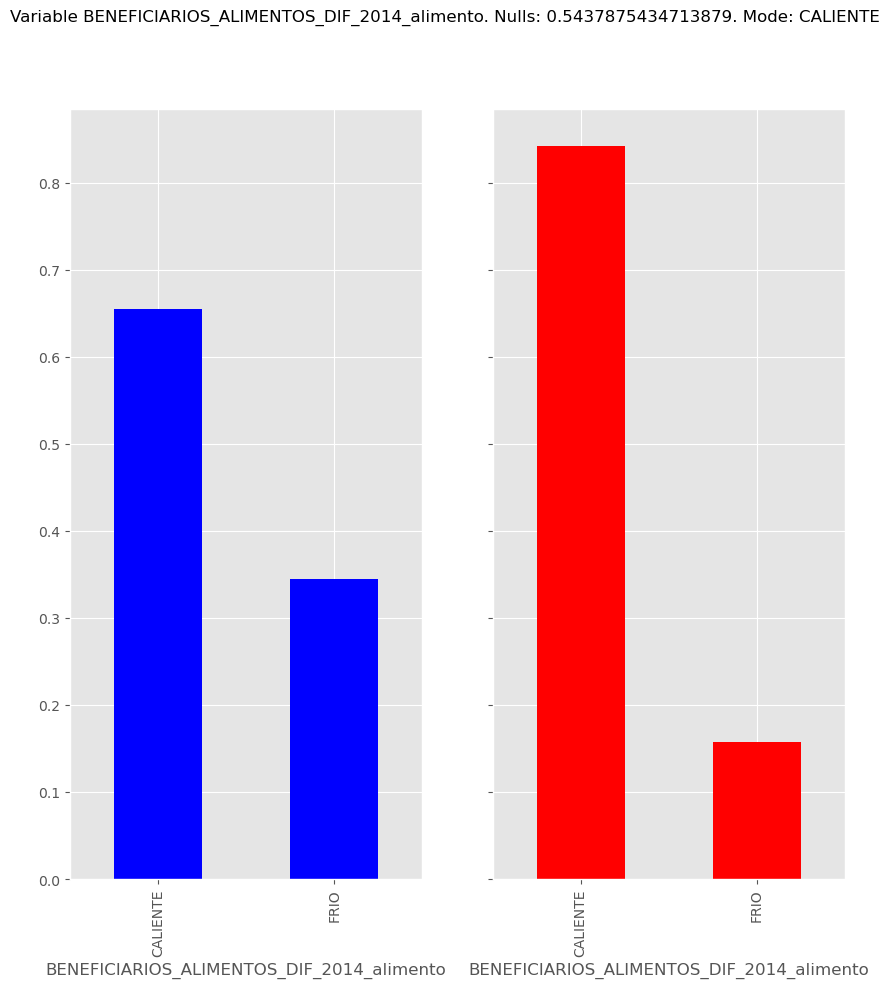

In [29]:
copy = df.copy()
object_cols = df.select_dtypes(include=['object']).columns

threshold = 0.7

for variable in object_cols:
    nulls = copy[variable].isnull().mean()

    if 0 < nulls <= threshold:
        mode = copy[variable].mode().values[0]

        copy[variable].fillna(mode, inplace=True)

        fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,10))

        df[variable].value_counts(normalize=True).plot(kind='bar', color='blue', ax=ax1)

        copy[variable].value_counts(normalize=True).plot(kind='bar', color='red', ax=ax2)

        fig.suptitle(f'Variable {variable}. Nulls: {nulls}. Mode: {mode}', fontsize=12)

En este caso solo una variable entra en el threshold y la distribución se mantiene. 


El problema con rellenar datos es que le ponemos "de nuestra cuchara" a los datos. 

Esto en términos cuantitativos implica cambiar el ratio de población, antes por cada 10 datos había seis `CALIENTE`, hoy hay poco más de ocho.


#### Llenado con datos atípicos

Otra estrategia para llenar datos nulos es el llenado con un dato atípico. 

Observemos alguna variable y veamos entre qué valores se encuentra su distribución. 

In [ ]:
variable = 'CONECTIVIDAD_mbs'



Nos debemos preguntar ahora: 

¿El mínimo y el máximo representan estos valores _en producción_? 


Si la respuesta es "no", ¿cuáles sí? 

El objetivo es encontrar un número que no lo sea. 

La distribución "cambia", por lo que este método debería de aplicarse si se van a usar modelos de árboles. 


Veamos cómo se ve un árbol de decisión*:






*: Cabe aclarar que no estamos viendo cómo se generan los nodos, eso entrará en el siguiente módulo.

![](normal.png)

Cuando nosotros agregamos un dato atípico para sustituir nulos el árbol tiene que incorporar ese _step_ como parte de sus decisiones: 

![](alterado.png)